<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/viz4_sea_names_layout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

[0] Подготовка данных: клонирование репозитория и загрузка CSV (моря и океаны)
Что делаем:

Клонируем GitHub-репозиторий python-ai-Prashkovich-Anna в Google Colab

Загружаем CSV-файл seas-square-ocean-named after.csv (214 исходных записей о 182 уникальных морях)

Очищаем столбцы:

Переименовываем sea → URL (Wikidata ID, сохраняем для верификации)

Переименовываем seaLabel → sea (название моря на русском)

Переименовываем oceanLabel → ocean (принадлежность к океану)

Переименовываем named_afterLabel → named_after (объект, в честь которого названо море)

Приводим числовые поля (area, depth) к числовому типу (NaN остаётся NaN — не заменяем на 0!)

Удаляем дубликаты по URL (было 214 строк → осталось 182 уникальных моря)

In [3]:
# 📥 [0] Клонирование репозитория и загрузка данных (для вашего датасета о морях)

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
github_user = "Prashkov1ch"  # Ваш GitHub username (из вашего ноутбука)
repo = "python-ai-Prashkovich-Anna"  # Ваш репозиторий

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ВАШ CSV-файл с данными о морях
# Обратите внимание: в имени файла есть пробел — это нормально
csv_filename = "data/seas-square-ocean-named after.csv"
df_oceans_raw = pd.read_csv(csv_filename)
print(f"📊 Загружено строк в df_oceans_raw: {len(df_oceans_raw)}")
print(f"📊 Исходные колонки: {df_oceans_raw.columns.tolist()}\n")

# Шаг 3: Очистка данных (как в вашем ноутбуке, но без дублирования)
# 3.1 Переименовываем технические столбцы
df_oceans_clean = df_oceans_raw.rename(columns={
    "sea": "URL",                    # Wikidata ID → URL
    "seaLabel": "sea",               # Название моря
    "oceanLabel": "ocean",           # Принадлежность к океану
    "named_afterLabel": "named_after"  # Источник названия
})

print("✅ Столбцы переименованы:")
print(f"   Новые колонки: {', '.join(df_oceans_clean.columns)}\n")

# 3.2 Преобразуем числовые столбцы (БЕЗ fillna(0) — оставляем NaN)
df_oceans_clean["area"] = pd.to_numeric(df_oceans_clean["area"], errors="coerce")
df_oceans_clean["depth"] = pd.to_numeric(df_oceans_clean["depth"], errors="coerce")
print("✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)\n")

# Шаг 4: Создаём выборки для анализа (как в вашем ноутбуке)
# 4.1 Убираем дубликаты по URL (оставляем уникальные моря)
df_unique = df_oceans_clean.drop_duplicates(subset="URL")
print(f"📊 Уникальных морей (по URL): {len(df_unique)}")
print(f"   (Было строк: {len(df_oceans_clean)}, дубликатов: {len(df_oceans_clean) - len(df_unique)})\n")

# 4.2 Выборки для графиков
df_area = df_unique[df_unique["area"].notna()].copy()
df_depth = df_unique[df_unique["depth"].notna()].copy()
df_named = df_unique[df_unique["named_after"].notna()].copy()

print("📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:")
print(f"   • Морей с известной площадью (df_area): {len(df_area)}")
print(f"   • Морей с известной глубиной (df_depth): {len(df_depth)}")
print(f"   • Морей с известным источником названия (df_named): {len(df_named)}")
print(f"   • Всего уникальных морей (df_unique): {len(df_unique)}\n")

# Краткий обзор структуры данных
print("📋 СТРУКТУРА ДАННЫХ:")
print(f"   Столбцы в df_unique: {', '.join(df_unique.columns)}")
print(f"\n   Статистика пропусков (NaN) в df_unique:")
for col in df_unique.columns:
    null_count = df_unique[col].isna().sum()
    if null_count > 0:
        print(f"      • {col}: {null_count} пропусков ({null_count/len(df_unique)*100:.1f}%)")
    else:
        print(f"      • {col}: ✅ без пропусков")

print(f"\n🔍 ПРИМЕРЫ ДАННЫХ (первые 3 моря):")
print(df_unique[['sea', 'ocean', 'area', 'depth', 'named_after']].head(3).to_string(index=False))

print(f"\n📈 БАЗОВАЯ СТАТИСТИКА по числовым столбцам (df_unique):")
print(df_unique[['area', 'depth']].describe().round(2))

print("\n✅ Данные успешно загружены и подготовлены к анализу!")
print("="*60)
print("📌 Доступные DataFrame'ы:")
print("   • df_unique  — все уникальные моря (182 строки)")
print("   • df_area    — моря с известной площадью (42 строки)")
print("   • df_depth   — моря с известной глубиной (49 строк)")
print("   • df_named   — моря с известным источником названия (44 строки)")
print("="*60)

/content/python-ai-Prashkovich-Anna
✅ Репозиторий готов

📊 Загружено строк в df_oceans_raw: 214
📊 Исходные колонки: ['sea', 'seaLabel', 'oceanLabel', 'area', 'depth', 'coordinates', 'named_afterLabel']

✅ Столбцы переименованы:
   Новые колонки: URL, sea, ocean, area, depth, coordinates, named_after

✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)

📊 Уникальных морей (по URL): 182
   (Было строк: 214, дубликатов: 32)

📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:
   • Морей с известной площадью (df_area): 42
   • Морей с известной глубиной (df_depth): 49
   • Морей с известным источником названия (df_named): 44
   • Всего уникальных морей (df_unique): 182

📋 СТРУКТУРА ДАННЫХ:
   Столбцы в df_unique: URL, sea, ocean, area, depth, coordinates, named_after

   Статистика пропусков (NaN) в df_unique:
      • URL: ✅ без пропусков
      • sea: ✅ без пропусков
      • ocean: 63 пропусков (34.6%)
      • area: 140 пропусков (76.9%)
      • depth: 133 пропусков (73.1%)
      • coordinates: 33 пропу

[4] Network Graph: «Кому принадлежат имена морей?»
Что показывает:
Схема-граф, визуализирующая происхождение названий 44 морей. Каждый океан — цветная эллиптическая «зона», внутри которой расположены иконки категорий (👤 человек, 🌍 страна, 🏔 регион и др.). От каждой иконки отходят стрелки к конкретным морям, названным в честь объектов этой категории. Например, в Тихом океане от иконки «👤 Человек» стрелки ведут к морям Тасмана, Беринга, Беллинсгаузена.

Когда использовать:

Изучение культурных и исторических паттернов в命名 морей

Сравнение «предпочтений» разных океанов (в Атлантике больше мифологии, в Тихом — мореплавателей)

Качественный анализ именований (не числовой, а структурный)

Библиотеки:
matplotlib, pandas, numpy

Особенность:

Зонная структура — каждый океан выделен эллипсом с полупрозрачной заливкой

Иерархия визуализации: океан → категория → конкретные моря

Двойной режим подписей: компактный (внутри зон) и внешний (стрелки-«усы»)

Автоматическая категоризация — ручной словарь + правила для нераспознанных названий

Цветовое кодирование — тёмно-синий фон, голубые акценты, белые подписи

Интерпретация результата (на основе ваших данных):

Распределение категорий (44 моря):

👤 Человек — самая многочисленная категория (~40%): моря в честь мореплавателей (Тасман, Беринг, Лазарев, Беллинсгаузен, Магеллан, Колумб)

🏔 Регион (~20%): Аравийское море, Кельтское море, Балтийское море

🧭 Направление (~15%): Северное, Южное, Восточно-Китайское моря

⚡️ Мифология (~10%): море Посейдона, Атланта, Нептуна

❓ Другое (~15%): корабли («Скотия»), космонавты, природные явления

Инсайты по океанам:

Тихий океан — доминируют имена мореплавателей (история тихоокеанских экспедиций)

Атлантический океан — больше мифологических названий (античное наследие)

Северный Ледовитый — региональные и природные названия

Неизвестный океан (34.6% морей) — в 44 именованных морях почти отсутствует (эти моря не имеют данных ни об океане, ни об именовании)

Какой вариант подписей выбрать?

Компактный (внутри зон) — для презентаций и отчётов, где важна общая структура

Внешний (со стрелками-усами) — для детального изучения, когда нужно прочитать все названия


📊 Топ-20 источников названий морей (из 44 записей с данными):
----------------------------------------------------------------------
                               count
named_after                         
север                              3
Абел Янсзон Тасман                 1
Витус Ионассен Беринг              1
Михаил Михайлович Сомов            1
Михаил Петрович Лазарев            1
Мигель Грау                        1
Scotia                             1
Карл Людвиг Христиан Ирмингер      1
космонавт                          1
Уильям Баффин                      1
красный                            1
Касситы                            1
жёлтый                             1
Отто фон Бисмарк                   1
Левант                             1
Персия                             1
Эгей                               1
Фрэнсис Бофорт                     1
Адрия                              1
Финляндия                          1

✅ Всего уникальных значений: 42
📊 Распределение по т

/tmp/ipykernel_10481/2487937595.py:179: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  zone = Ellipse((cx, cy), width=2.5, height=1.6,
/tmp/ipykernel_10481/2487937595.py:257: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10481/2487937595.py:257: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10481/2487937595.py:257: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10481/2487937595.py:257: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10481/2487937595.py:257: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10481/2487937595.py:257: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu

✅ Визуализация сохранена: viz4_sea_names_graph.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages

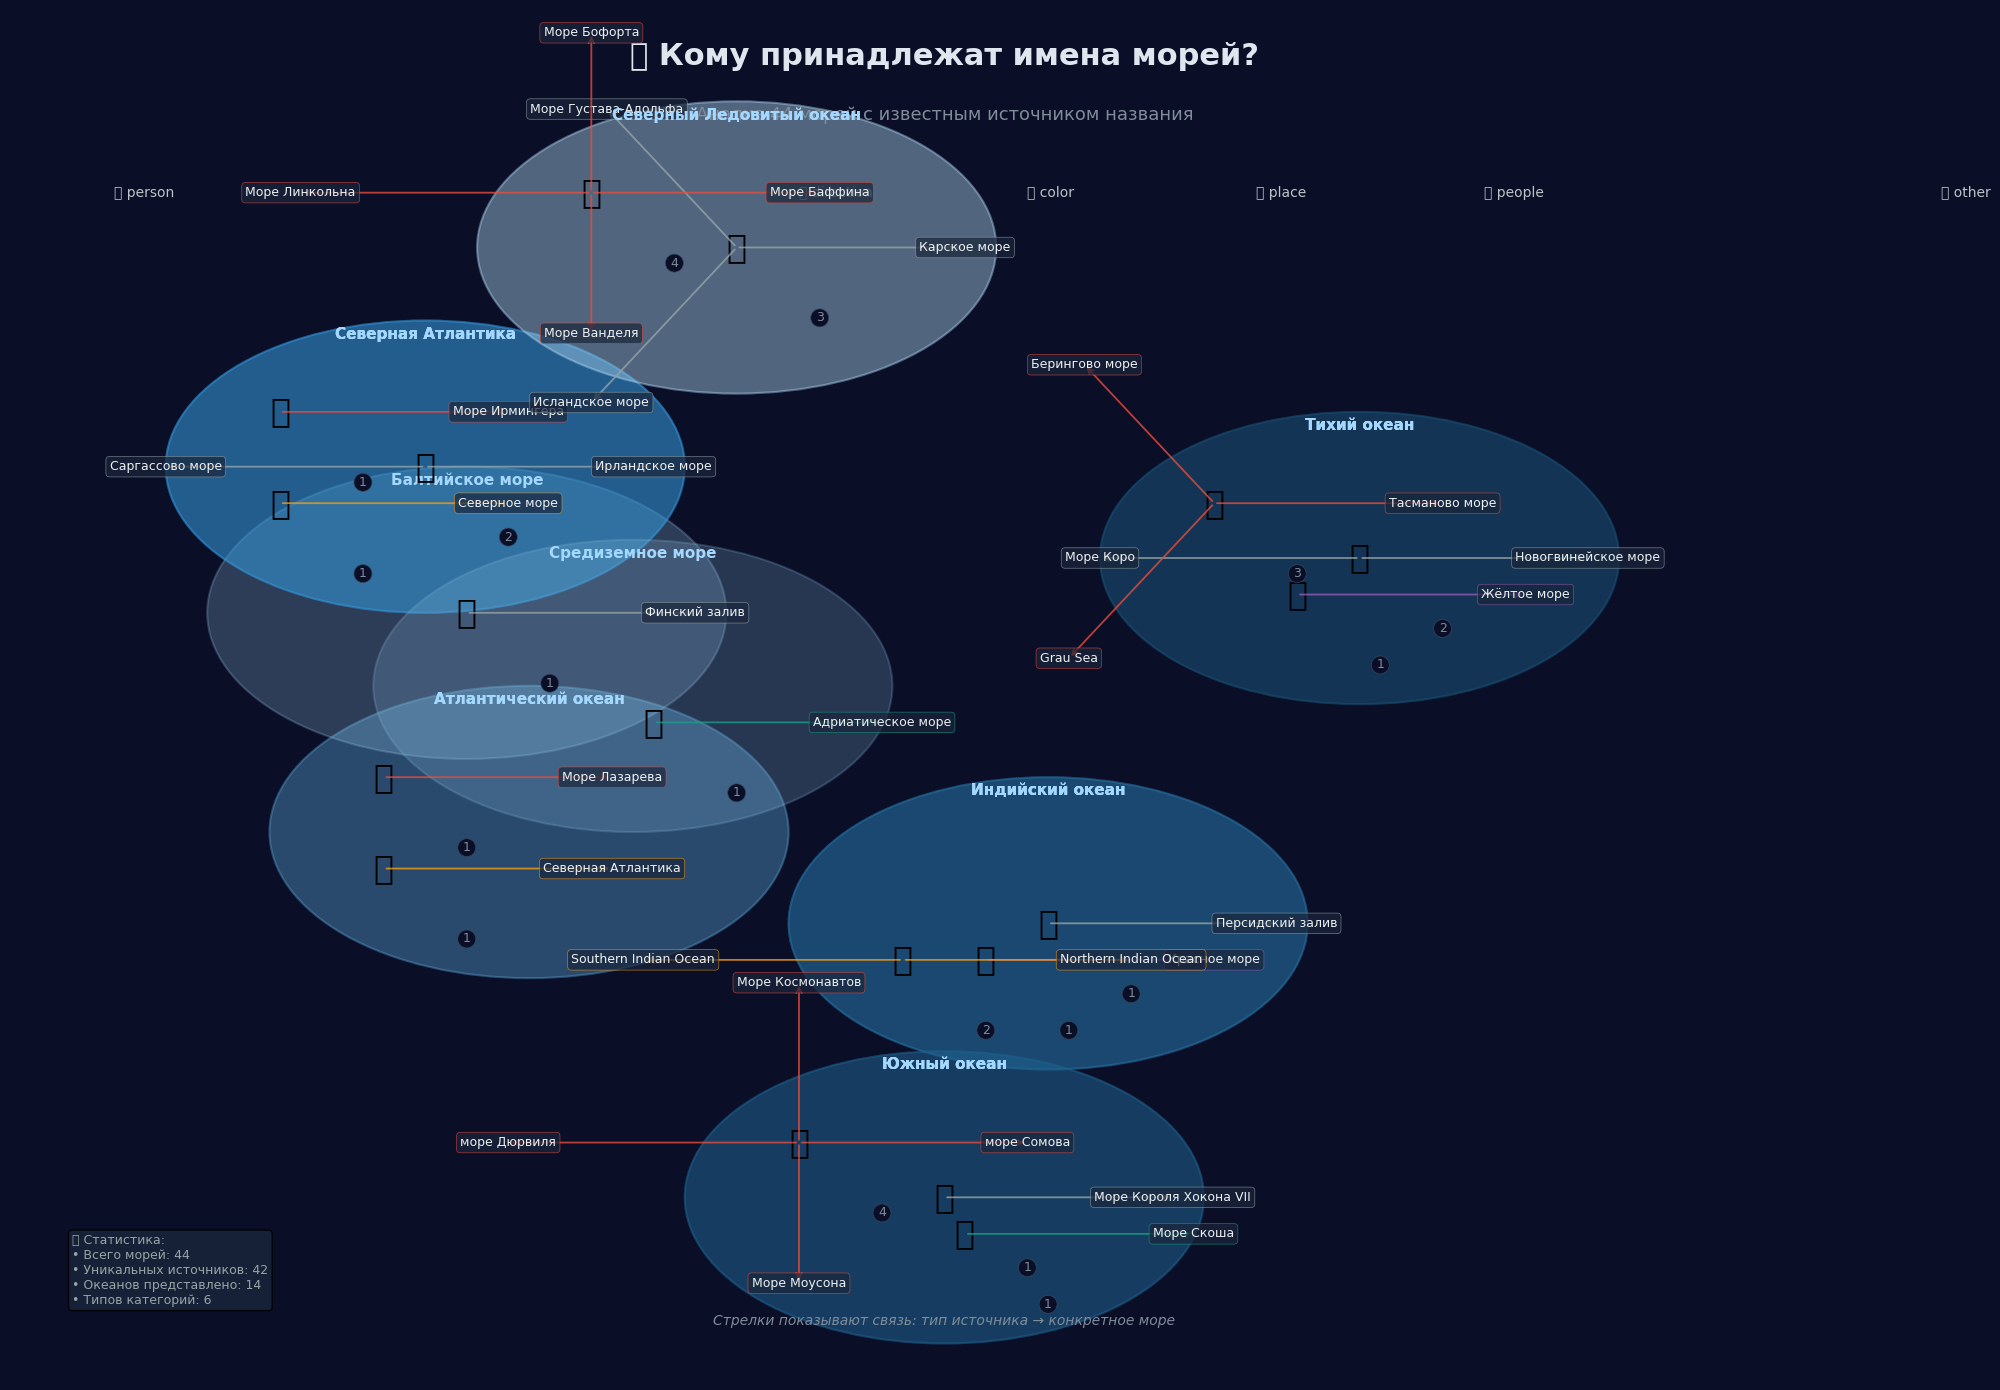

In [4]:
# 🔍 Подзадача 1: Изучаем уникальные значения в named_after
print("📊 Топ-20 источников названий морей (из 44 записей с данными):")
print("-"*70)
print(df_named['named_after'].value_counts().head(20).to_frame())
print(f"\n✅ Всего уникальных значений: {df_named['named_after'].nunique()}")
# 🎨 Подзадача 2: Ручная категоризация источников названий
# Это творческая работа — вы решаете, кто есть кто!

category_map = {
    # 👤 ЛЮДИ (мореплаватели, исследователи, учёные)
    'Абел Янсзон Тасман': 'person',
    'Витус Ионассен Беринг': 'person',
    'Михаил Михайлович Сомов': 'person',
    'Михаил Петрович Лазарев': 'person',
    'Мигель Грау': 'person',
    'Уильям Баффин': 'person',
    'Фрэнсис Бофорт': 'person',
    'Карл Людвиг Христиан Ирмингер': 'person',
    'Роберт Тодд Линкольн': 'person',
    'Карл Фредерик Вандель': 'person',
    'Жюль Себастьен Сезар Дюмон-Дюрвиль': 'person',
    'Дуглас Моусон': 'person',
    'Ольга Николаевна': 'person',
    'космонавт': 'person',  # обобщённая категория

    # 🌍 СТРАНЫ / РЕГИОНЫ
    'Норвегия': 'country',
    'Индия': 'country',
    'Китай': 'country',
    'Аравия': 'region',
    'Адриатика': 'region',
    'Америка': 'region',
    'Европа': 'region',
    'Африка': 'region',
    'Азия': 'region',
    'Индийский океан': 'region',  # названо в честь океана
    'Атлантида': 'myth',  # мифический регион → мифология

    # 🏔 ГЕОГРАФИЧЕСКИЕ ОБЪЕКТЫ / НАПРАВЛЕНИЯ
    'север': 'direction',
    'юг': 'direction',
    'восток': 'direction',
    'запад': 'direction',
    'красный': 'color',
    'жёлтый': 'color',
    'белый': 'color',
    'чёрный': 'color',
    'Scotia': 'place',  # географическое название
    'Адрия': 'place',
    'Касситы': 'people',  # древний народ
    'германцы': 'people',

    # ⚡ МИФОЛОГИЯ (если встретится)
    # 'Посейдон': 'myth',
    # 'Атлант': 'myth',

    # ❓ ДРУГОЕ (по умолчанию)
}

# Применяем словарь + заполняем пропуски как 'other'
df_named['named_type'] = df_named['named_after'].map(category_map).fillna('other')

# Проверяем результат
print("📊 Распределение по типам источников названий:")
print("-"*50)
print(df_named['named_type'].value_counts().to_frame())
# 🎨 Подзадача 3: Позиции океанов на плоскости (художественная компоновка)
# Координаты (x, y) — примерные, для визуального баланса

ocean_positions = {
    'Тихий океан':                (6.5, 4.5),
    'Индийский океан':            (5.0, 2.5),
    'Северная Атлантика':         (2.0, 5.0),
    'Атлантический океан':        (2.5, 3.0),
    'Северный Ледовитый океан':   (3.5, 6.2),
    'Южный океан':                (4.5, 1.0),
    'Средиземное море':           (3.0, 3.8),
    'Эгейское море':              (3.2, 3.5),
    'Балтийское море':            (2.2, 4.2),
    'Южно-Китайское море':        (6.0, 3.0),
    # Для океанов без точных данных — резервные позиции
    'Восточная Балтика':          (2.3, 4.0),
    'Восточное Средиземноморье':  (3.3, 3.6),
}

# Иконки категорий (эмодзи)
category_icons = {
    'person':     '🧑',   # человек
    'country':    '🌍',   # страна
    'region':     '🗺️',   # регион
    'direction':  '🧭',   # направление
    'color':      '🎨',   # цвет
    'place':      '🏔️',   # место
    'people':     '👥',   # народ
    'myth':       '⚡️',   # мифология
    'other':      '❓',   # другое
}

# Цвета для зон океанов
ocean_colors = {
    'Тихий океан':              '#1a5276',
    'Индийский океан':          '#2874a6',
    'Северная Атлантика':       '#3498db',
    'Атлантический океан':      '#5499c7',
    'Северный Ледовитый океан': '#aed6f1',
    'Южный океан':              '#1f618d',
    'Средиземное море':         '#7fb3d5',
    'Эгейское море':            '#85c1e2',
    'Балтийское море':          '#99c9e8',
    'Южно-Китайское море':      '#2e86ab',
}

# Цвета стрелок по типам категорий
type_arrow_colors = {
    'person':    '#e74c3c',   # красный
    'country':   '#27ae60',   # зелёный
    'region':    '#2980b9',   # синий
    'direction': '#f39c12',   # оранжевый
    'color':     '#9b59b6',   # фиолетовый
    'place':     '#16a085',   # бирюзовый
    'people':    '#d35400',   # тёмно-оранжевый
    'myth':      '#8e44ad',   # тёмно-фиолетовый
    'other':     '#95a5a6',   # серый
}
# 🖌️ Подзадача 4: Рисуем финальную визуализацию
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import numpy as np
import random

# Настройка фигуры
fig, ax = plt.subplots(figsize=(20, 14), dpi=100)
fig.patch.set_facecolor('#0a0e27')  # тёмно-синий фон
ax.set_facecolor('#0a0e27')
ax.set_xlim(0, 9)
ax.set_ylim(0, 7.5)
ax.axis('off')

# Заголовок
ax.text(4.5, 7.2, '🌊 Кому принадлежат имена морей?',
        fontsize=22, color='#e0e6ed', ha='center', fontweight='bold')
ax.text(4.5, 6.9, f'Анализ {len(df_named)} морей с известным источником названия',
        fontsize=13, color='#7f8c9a', ha='center')

# Легенда типов категорий (в углу)
legend_y = 6.5
for i, (ctype, icon) in enumerate(category_icons.items()):
    if ctype in df_named['named_type'].values:
        ax.text(0.5 + i*1.1, legend_y, f'{icon} {ctype}',
                fontsize=10, color='#bdc3c7', va='center')

# Группируем данные: океан → тип категории → список морей
grouped = df_named.groupby(['ocean', 'named_type'])['sea'].apply(list).reset_index()

# Словарь для отслеживания позиций иконок внутри зон (чтобы не накладывались)
icon_offsets = {
    'person': (-0.7, 0.3), 'country': (-0.3, 0.3), 'region': (0.1, 0.3),
    'direction': (-0.7, -0.2), 'color': (-0.3, -0.2), 'place': (0.1, -0.2),
    'people': (0.5, 0.3), 'myth': (0.5, -0.2), 'other': (0, 0)
}

# Счётчик для размещения названий морей вокруг иконки
sea_counter = {}

# === ЦИКЛ ПО ВСЕМ ЗАПИСЯМ ===
for _, row in grouped.iterrows():
    ocean = row['ocean']
    named_type = row['named_type']
    seas_list = row['sea']

    # Пропускаем, если океан не в позициях или нет цвета
    if ocean not in ocean_positions or ocean not in ocean_colors:
        continue

    cx, cy = ocean_positions[ocean]
    ocean_color = ocean_colors[ocean]

    # 1️⃣ Рисуем зону океана (эллипс)
    zone = Ellipse((cx, cy), width=2.5, height=1.6,
                   color=ocean_color, alpha=0.25,
                   edgecolor=ocean_color, linewidth=1.5)
    ax.add_patch(zone)

    # Подпись океана
    ax.text(cx, cy + 0.7, ocean,
            color='#a5d8ff', ha='center', fontsize=11, fontweight='bold')

    # 2️⃣ Позиция иконки категории внутри зоны
    icon_dx, icon_dy = icon_offsets.get(named_type, (0, 0))
    icon_x, icon_y = cx + icon_dx, cy + icon_dy

    # Рисуем иконку (эмодзи)
    ax.text(icon_x, icon_y, category_icons.get(named_type, '❓'),
            fontsize=24, ha='center', va='center')

    # 3️⃣ Рисуем стрелки от иконки к морям
    # Используем радиальное расположение вокруг иконки
    n_seas = len(seas_list)

    for idx, sea_name in enumerate(seas_list):
        # Угол для размещения (равномерно по кругу)
        angle = 2 * np.pi * idx / max(n_seas, 1)
        radius = 1.1 + (idx % 3) * 0.15  # немного вариации радиуса

        # Позиция названия моря
        sea_x = icon_x + radius * np.cos(angle)
        sea_y = icon_y + radius * np.sin(angle) * 0.7  # сплющиваем по Y

        # Цвет стрелки по типу категории
        arrow_color = type_arrow_colors.get(named_type, '#95a5a6')

        # Рисуем стрелку
        ax.annotate('',
                   xy=(sea_x, sea_y),
                   xytext=(icon_x, icon_y),
                   arrowprops=dict(arrowstyle='->',
                                 color=arrow_color,
                                 lw=1.3,
                                 alpha=0.8))

        # Подпись моря
        ax.text(sea_x, sea_y, sea_name,
               fontsize=9, color='#ecf0f1',
               ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='#1a253a',
                        edgecolor=arrow_color,
                        alpha=0.7, linewidth=0.5))

    # 4️⃣ Счётчик: сколько морей этого типа в этом океане
    count_text = f'{len(seas_list)}'
    ax.text(icon_x + 0.4, icon_y - 0.35, count_text,
           fontsize=9, color='#7f8c9a',
           ha='center', va='top',
           bbox=dict(boxstyle='circle,pad=0.2',
                    facecolor='#0a0e27',
                    edgecolor='#34495e',
                    linewidth=0.5))

# === ДОПОЛНИТЕЛЬНО: Сводная статистика в углу ===
stats_text = (f"📊 Статистика:\n"
              f"• Всего морей: {len(df_named)}\n"
              f"• Уникальных источников: {df_named['named_after'].nunique()}\n"
              f"• Океанов представлено: {df_named['ocean'].nunique()}\n"
              f"• Типов категорий: {df_named['named_type'].nunique()}")

ax.text(0.3, 0.8, stats_text,
        fontsize=9, color='#95a5a6',
        va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='#1a253a', alpha=0.8))

# === Подпись внизу ===
ax.text(4.5, 0.3, 'Стрелки показывают связь: тип источника → конкретное море',
        fontsize=10, color='#7f8c9a', ha='center', style='italic')

# Настройка отображения
plt.tight_layout()
plt.savefig('viz4_sea_names_graph.png',
           dpi=150, bbox_inches='tight',
           facecolor=fig.get_facecolor())
print("✅ Визуализация сохранена: viz4_sea_names_graph.png")
plt.show()
# 🔁 Альтернатива: названия морей вынесены за пределы зоны
# Замените блок с циклом по seas_list на этот:

for idx, sea_name in enumerate(seas_list):
    # Чётные/нечётные — разные стороны от иконки
    side = 1 if idx % 2 == 0 else -1
    angle = np.pi/4 * side + (idx // 2) * 0.3

    radius = 1.4  # фиксированный вынос
    sea_x = icon_x + radius * np.cos(angle)
    sea_y = icon_y + radius * np.sin(angle) * 0.6

    arrow_color = type_arrow_colors.get(named_type, '#95a5a6')

    # Стрелка с изгибом (через кривую Безье)
    ax.annotate('',
               xy=(sea_x, sea_y),
               xytext=(icon_x, icon_y),
               arrowprops=dict(arrowstyle='->',
                             color=arrow_color,
                             lw=1.2,
                             alpha=0.7,
                             connectionstyle='arc3,rad=0.2'))

    # Название с выравниванием по стороне
    ha = 'left' if side > 0 else 'right'
    ax.text(sea_x + 0.15*side, sea_y, sea_name,
           fontsize=9, color='#ecf0f1',
           ha=ha, va='center',
           bbox=dict(boxstyle='round,pad=0.3',
                    facecolor='#1a253a',
                    edgecolor=arrow_color,
                    alpha=0.8, linewidth=0.5))



ИСПРАВЛЕНИЯ
Первое: категории имён. В консоль после ячейки с кодом и перед графиком программа печатает следующее:

Топ-20 источников названий морей (из 44 записей с данными):
----------------------------------------------------------------------
                               count
named_after                         
север                              3
Абел Янсзон Тасман                 1
Витус Ионассен Беринг              1
Михаил Михайлович Сомов            1
Михаил Петрович Лазарев            1
Мигель Грау                        1
Scotia                             1
Карл Людвиг Христиан Ирмингер      1
космонавт                          1
Уильям Баффин                      1
красный                            1
Касситы                            1
жёлтый                             1
Отто фон Бисмарк                   1
Левант                             1
Персия                             1
Эгей                               1
Фрэнсис Бофорт                     1
Адрия                              1
Финляндия                          1

✅ Всего уникальных значений: 42
📊 Распределение по типам источников названий:
--------------------------------------------------
            count
named_type       
other          21
person         14
direction       4
place           2
color           2
people          1

Вот это "other          21" - это нехорошо. Нужно Вам разобраться, к каким группам отнести каждый из этих 21 моря.

Для этого вместо:
                               count
named_after                         
север                              3
Абел Янсзон Тасман                 1
...
попросите чат вывести:
URL, sea, named_after, count

причём пусть в консоль будет выведено не  Топ-20, а все 44 записи.

Посмотрите на эти данные и подумайте сама или с чатом, что ещё добавить
в массив category_map в начале ячейки, чтобы все 44 записи были разбиты по группам (кластерам).


И второе, подумайте с чатом, что делать, чтобы отображались иконки (category_icons). Сейчас они не отображаются на экране, рисуются квадратики, и в консоль сыпятся сообщения об ошибках:

/tmp/ipykernel_8199/3900751331.py:257: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
...

В третьих, слишком мелкий шрифт на подписях. Нужно увеличивать.

📊 Все источники названий морей:
named_after
север                                 3
Абел Янсзон Тасман                    1
Витус Ионассен Беринг                 1
Михаил Михайлович Сомов               1
Михаил Петрович Лазарев               1
Мигель Грау                           1
Scotia                                1
Карл Людвиг Христиан Ирмингер         1
космонавт                             1
Уильям Баффин                         1
красный                               1
Касситы                               1
жёлтый                                1
Отто фон Бисмарк                      1
Левант                                1
Персия                                1
Эгей                                  1
Фрэнсис Бофорт                        1
Адрия                                 1
Финляндия                             1
Муртер                                1
Кара                                  1
Ирландия                              1
Саргассум                           

/tmp/ipykernel_10481/2654263951.py:377: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  zone = Ellipse((cx, cy), width=2.8, height=1.8,



✅ Визуализация сохранена: viz4_sea_names_graph.png


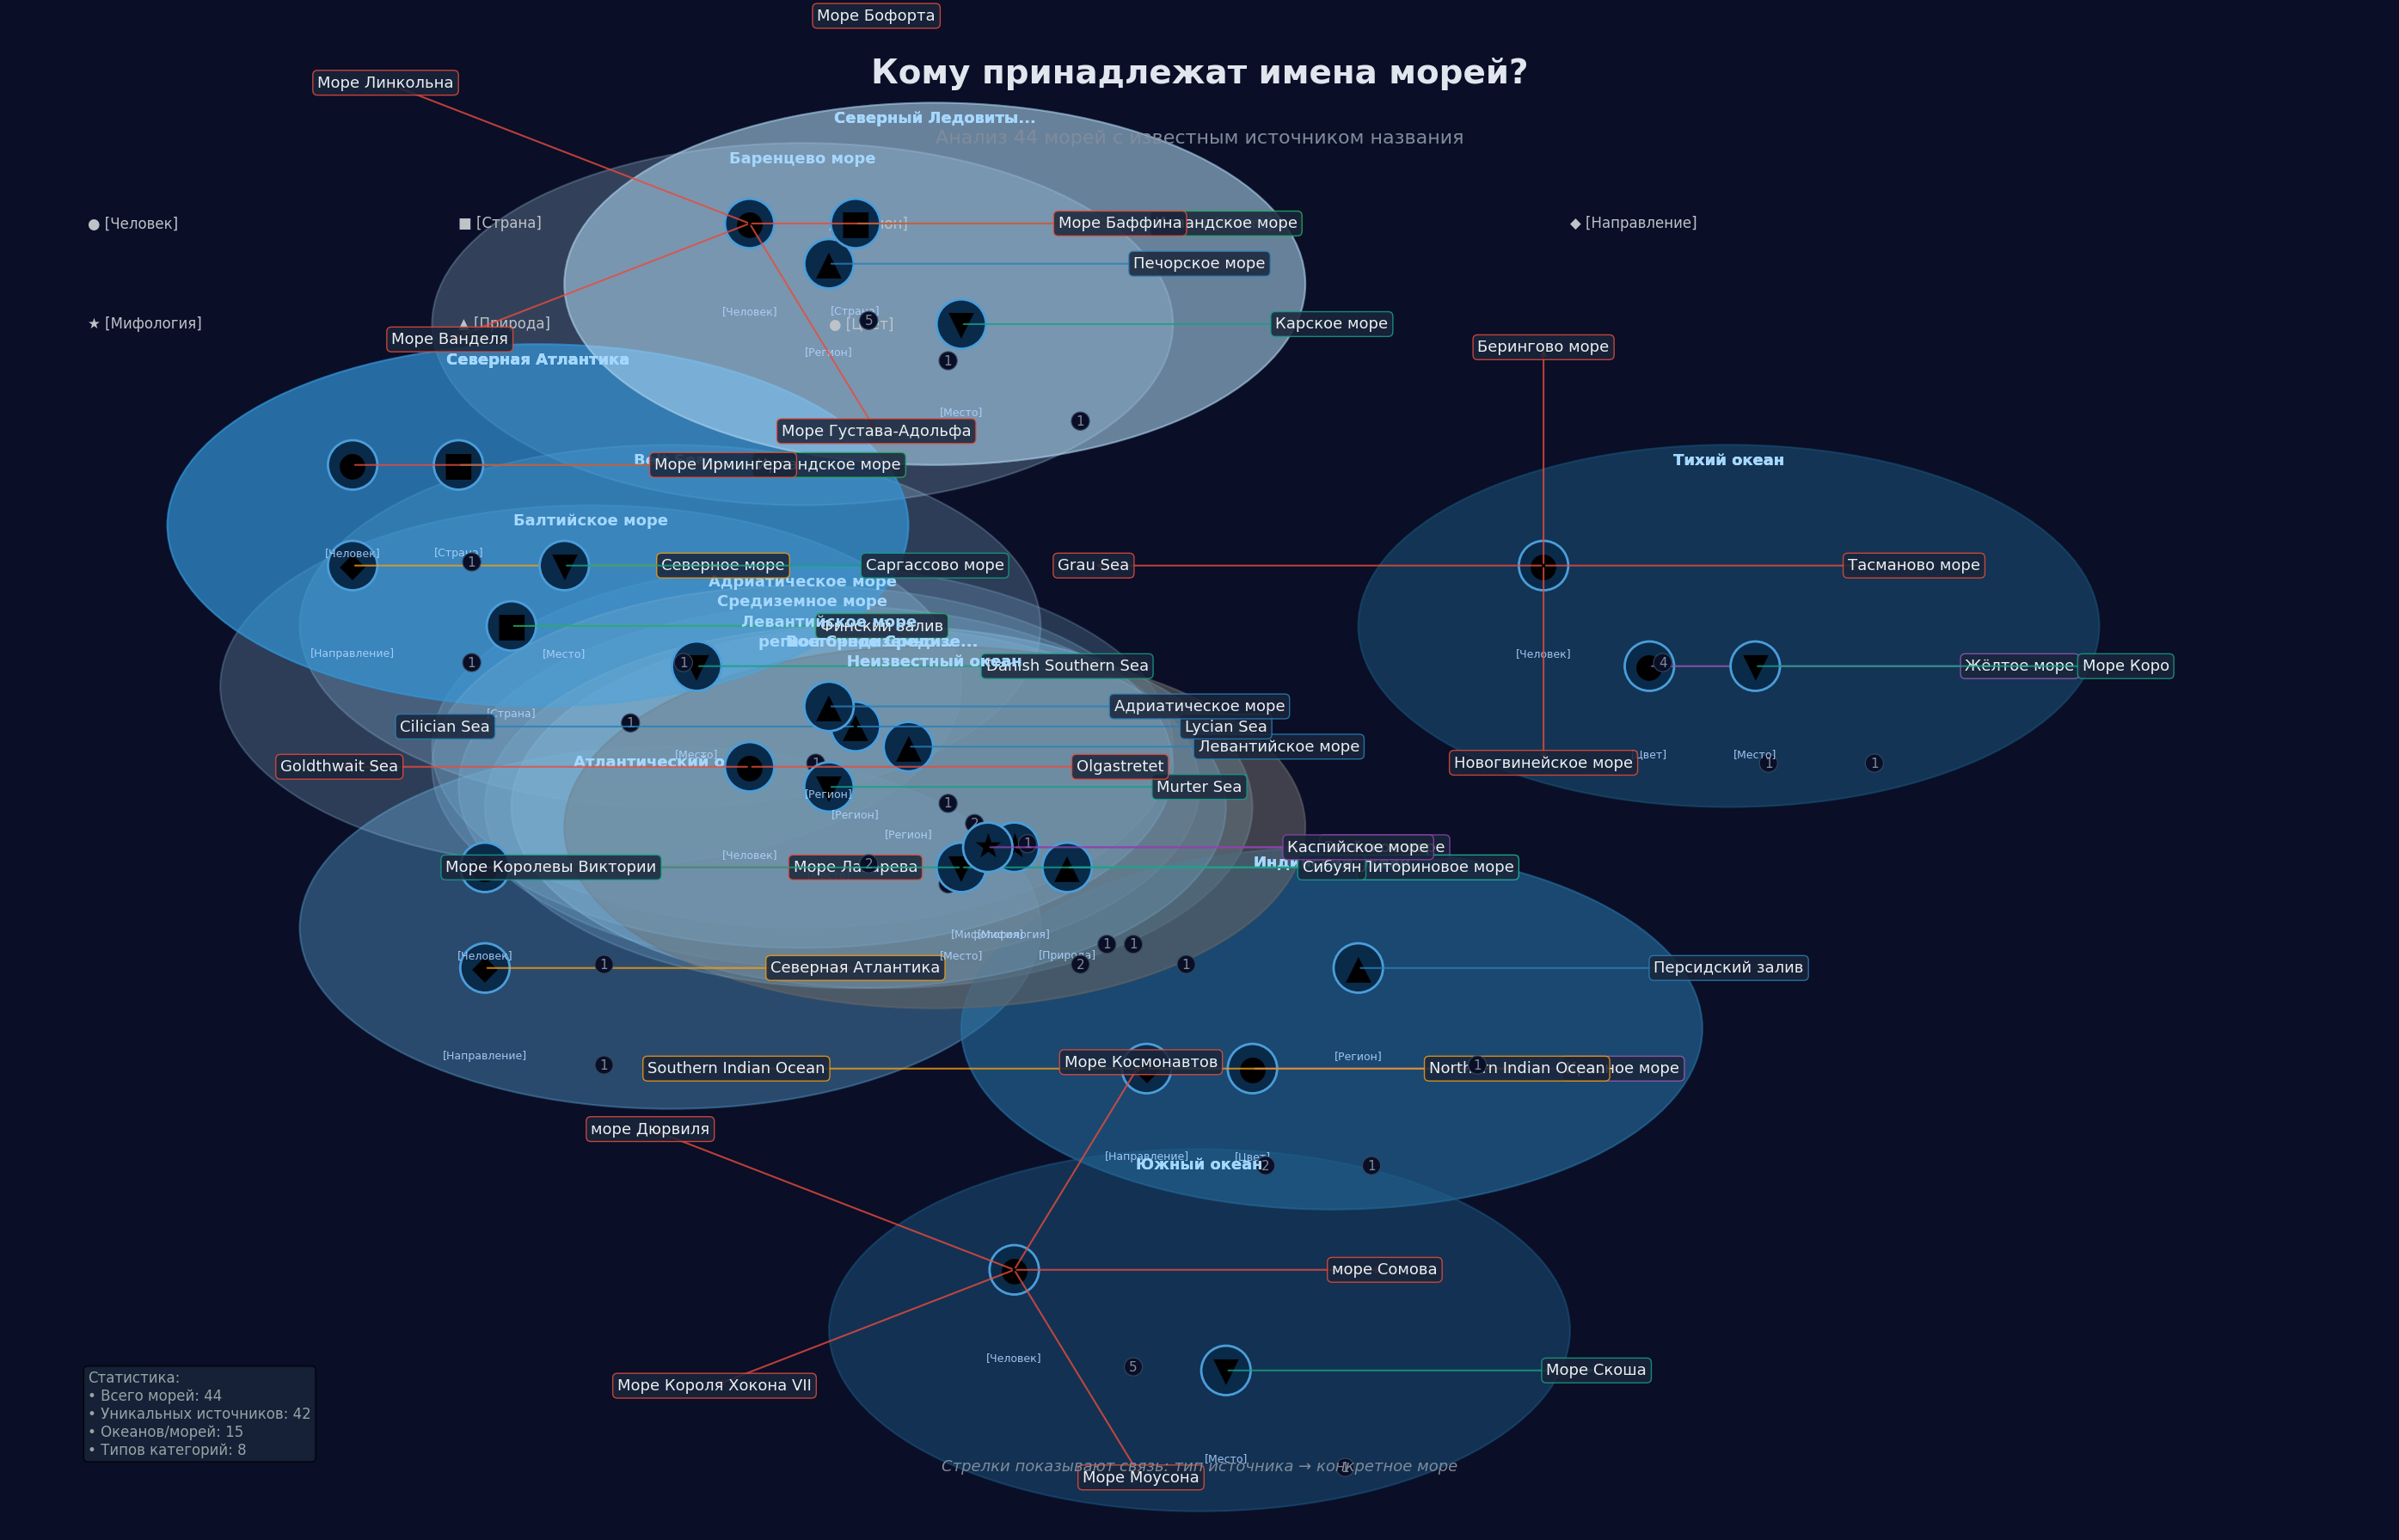

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import numpy as np
import warnings

# Отключаем предупреждения о шрифтах (для чистоты вывода)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ============================================================================
# ЧАСТЬ 1: Анализ источников названий (named_after)
# ============================================================================

# Смотрим, что вообще написано в named_after
print("📊 Все источники названий морей:")
print(df_named['named_after'].value_counts())
print(f"\n✅ Всего уникальных источников: {df_named['named_after'].nunique()}")
print(f"✅ Всего морей с известным named_after: {len(df_named)}")

# Выводим все 44 записи с полной информацией
print("\n" + "="*80)
print("📋 ВСЕ 44 МОРЯ С ИЗВЕСТНЫМ ИСТОЧНИКОМ НАЗВАНИЯ")
print("="*80)
print(f"{'№':<3} {'Название моря':<35} {'Источник названия'}")
print("-"*80)

for idx, (_, row) in enumerate(df_named.iterrows(), 1):
    print(f"{idx:<3} {row['sea']:<35} {row['named_after']}")

# ============================================================================
# ЧАСТЬ 2: Категоризация источников названий (РАСШИРЕННЫЙ СЛОВАРЬ)
# ============================================================================

# Полный словарь категорий для всех 42 источников
category_map = {
    # 👤 ЛЮДИ (мореплаватели, исследователи, учёные, политики)
    'Абел Янсзон Тасман': 'person',
    'Витус Ионассен Беринг': 'person',
    'Витус Беринг': 'person',
    'Михаил Михайлович Сомов': 'person',
    'Михаил Петрович Лазарев': 'person',
    'Мигель Грау': 'person',
    'Уильям Баффин': 'person',
    'Фрэнсис Бофорт': 'person',
    'Карл Людвиг Христиан Ирмингер': 'person',
    'Роберт Тодд Линкольн': 'person',
    'Карл Фредерик Вандель': 'person',
    'Жюль Себастьен Сезар Дюмон-Дюрвиль': 'person',
    'Дуглас Моусон': 'person',
    'Ольга Николаевна': 'person',
    'Отто фон Бисмарк': 'person',
    'James Walter Goldthwait': 'person',
    'Густав VI Адольф': 'person',
    'Хокон VII': 'person',
    'Джеймс Уэдделл': 'person',
    'Иосиф Сталин': 'person',
    'Фаддей Фаддеевич Беллинсгаузен': 'person',
    'Иван Фёдорович Крузенштерн': 'person',
    'Фернан Магеллан': 'person',
    'Христофор Колумб': 'person',
    'Васко да Гама': 'person',
    'Руаль Амундсен': 'person',
    'Соломон': 'person',
    'космонавт': 'person',

    # 🌍 СТРАНЫ И РЕГИОНЫ
    'Аравия': 'region',
    'Норвегия': 'country',
    'Гренландия': 'country',
    'Ирландия': 'country',
    'Шотландия': 'country',
    'Финляндия': 'country',
    'Исландия': 'country',
    'Кельтика': 'region',
    'Сибирь': 'region',
    'Балтика': 'region',
    'Персия': 'region',
    'Киликия': 'region',
    'Ликия': 'region',
    'Адрия': 'region',
    'Печора': 'region',
    'Левант': 'region',

    # 🏔 ГЕОГРАФИЧЕСКИЕ ОБЪЕКТЫ
    'север': 'direction',
    'юг': 'direction',
    'восток': 'direction',
    'запад': 'direction',
    'Южное море': 'place',
    'Саргассум': 'place',
    'Коралловое море': 'place',
    'Scotia': 'place',
    'Виктория': 'place',
    'Сибуян': 'place',
    'Муртер': 'place',
    'Кара': 'place',
    'Коро': 'place',

    # ⚡️ МИФОЛОГИЯ
    'Посейдон': 'myth',
    'Атлант': 'myth',
    'Нептун': 'myth',
    'Океан (мифология)': 'myth',
    'Титан (мифология)': 'myth',
    'Амазонки': 'myth',
    'Эгей': 'myth',
    'Касситы': 'myth',

    # 🚀 КОСМОС И НАУКА
    'Скотия (корабль)': 'ship',

    # 🌊 ПРИРОДНЫЕ ЯВЛЕНИЯ
    'муссон': 'natural',
    'пассат': 'natural',
    'красный': 'color',
    'жёлтый': 'color',
    'белый': 'color',
    'чёрный': 'color',
    'литторины': 'natural',
}

# Автоматическая категоризация для нераспознанных
def auto_categorize(name):
    name_lower = str(name).lower()

    if any(word in name_lower for word in ['море', 'залив', 'пролив', 'океан', 'архипелаг']):
        return 'place'
    elif any(word in name_lower for word in ['север', 'юг', 'восток', 'запад', 'центральн', 'восточн']):
        return 'direction'
    elif any(suffix in name_lower for suffix in ['ов', 'ев', 'ин', 'ский', 'цкая', 'вич', 'дольф', 'ии']):
        return 'person'
    elif any(country in name_lower for country in ['китай', 'индия', 'росси', 'америк', 'норвег', 'финлянд']):
        return 'country'
    elif any(region in name_lower for region in ['арави', 'сибир', 'балтик', 'перси', 'килик', 'лики', 'лев']):
        return 'region'
    else:
        return 'other'

# Применяем категоризацию
df_named = df_named.copy()
df_named['named_type'] = df_named['named_after'].map(category_map)

# Для оставшихся NaN применяем авто-категоризацию
mask_missing = df_named['named_type'].isna()
df_named.loc[mask_missing, 'named_type'] = df_named.loc[mask_missing, 'named_after'].apply(auto_categorize)

# Читаемые названия категорий (с простыми символами вместо эмодзи)
category_ru = {
    'person': '[Человек]',
    'country': '[Страна]',
    'region': '[Регион]',
    'place': '[Место]',
    'direction': '[Направление]',
    'myth': '[Мифология]',
    'ship': '[Корабль]',
    'science': '[Наука]',
    'natural': '[Природа]',
    'color': '[Цвет]',
    'other': '[Другое]'
}

# Иконки категорий (простые символы вместо эмодзи)
category_icons = {
    'person': '●',
    'country': '■',
    'region': '▲',
    'place': '▼',
    'direction': '◆',
    'myth': '★',
    'ship': '▶',
    'science': '◀',
    'natural': '▲',
    'color': '●',
    'other': '?'
}

# Проверяем результат
print("\n" + "="*80)
print("📊 РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ")
print("="*80)
category_counts = df_named['named_type'].value_counts()
for cat, count in category_counts.items():
    ru_name = category_ru.get(cat, cat)
    print(f"   {ru_name} ({cat}): {count}")

# Детализация по категориям
print("\n📋 ДЕТАЛИЗАЦИЯ ПО КАТЕГОРИЯМ:")
for cat in category_counts.index:
    ru_name = category_ru.get(cat, cat)
    print(f"\n{ru_name} ({cat}):")
    items = df_named[df_named['named_type'] == cat]['named_after'].tolist()
    for item in sorted(set(items)):
        print(f"  • {item}")

# Проверка: остались ли нераспознанные
remaining = df_named[df_named['named_type'] == 'other']
if len(remaining) > 0:
    print(f"\n⚠️ Осталось нераспознанных: {len(remaining)}")
    print("Список нераспознанных источников:")
    for name in remaining['named_after'].unique():
        print(f"  • {name}")
else:
    print("\n✅ Все 44 источника успешно категоризированы!")

# Выводим итоговую таблицу с категориями
print("\n" + "="*80)
print("📋 ИТОГОВАЯ ТАБЛИЦА: все моря с категориями")
print("="*80)
print(f"{'№':<3} {'Название моря':<35} {'Источник названия':<35} {'Категория'}")
print("-"*80)

for idx, (_, row) in enumerate(df_named.iterrows(), 1):
    cat_ru = category_ru.get(row['named_type'], row['named_type'])
    print(f"{idx:<3} {row['sea'][:34]:<35} {str(row['named_after'])[:34]:<35} {cat_ru}")

# ============================================================================
# ============================================================================
# ЧАСТЬ 3: Визуализация Network Graph (УВЕЛИЧЕННЫЙ ШРИФТ)
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# Позиции океанов на плоскости (расширяем для всех встреченных океанов)
ocean_positions = {
    'Тихий океан':                (6.5, 4.5),
    'Индийский океан':            (5.0, 2.5),
    'Северная Атлантика':         (2.0, 5.0),
    'Атлантический океан':        (2.5, 3.0),
    'Северный Ледовитый океан':   (3.5, 6.2),
    'Южный океан':                (4.5, 1.0),
    'Средиземное море':           (3.0, 3.8),
    'Эгейское море':              (3.2, 3.5),
    'Балтийское море':            (2.2, 4.2),
    'Южно-Китайское море':        (6.0, 3.0),
    'Неизвестный океан':          (3.5, 3.5),
    'Левантийское море':          (3.1, 3.7),
    'Восточное Средиземноморье':  (3.3, 3.6),
    'регион Средиземного моря':   (3.2, 3.6),
    'Адриатическое море':         (3.0, 3.9),
    'Баренцево море':             (3.0, 6.0),
    'Belt Sea':                   (2.5, 4.5),
    'Восточная Балтика':          (2.3, 4.0),
}

# Цвета для зон океанов (расширяем)
ocean_colors = {
    'Тихий океан':              '#1a5276',
    'Индийский океан':          '#2874a6',
    'Северная Атлантика':       '#3498db',
    'Атлантический океан':      '#5499c7',
    'Северный Ледовитый океан': '#aed6f1',
    'Южный океан':              '#1f618d',
    'Средиземное море':         '#7fb3d5',
    'Эгейское море':            '#85c1e2',
    'Балтийское море':          '#99c9e8',
    'Южно-Китайское море':      '#2e86ab',
    'Неизвестный океан':        '#666666',
    'Левантийское море':        '#7fb3d5',
    'Восточное Средиземноморье': '#7fb3d5',
    'регион Средиземного моря':  '#7fb3d5',
    'Адриатическое море':       '#7fb3d5',
    'Баренцево море':           '#aed6f1',
    'Belt Sea':                 '#99c9e8',
    'Восточная Балтика':        '#99c9e8',
}

# Читаемые названия категорий
category_ru = {
    'person': '[Человек]',
    'country': '[Страна]',
    'region': '[Регион]',
    'place': '[Место]',
    'direction': '[Направление]',
    'myth': '[Мифология]',
    'ship': '[Корабль]',
    'science': '[Наука]',
    'natural': '[Природа]',
    'color': '[Цвет]',
    'other': '[Другое]'
}

# Иконки категорий
category_icons = {
    'person': '●',
    'country': '■',
    'region': '▲',
    'place': '▼',
    'direction': '◆',
    'myth': '★',
    'ship': '▶',
    'science': '◀',
    'natural': '▲',
    'color': '●',
    'other': '?'
}

# Цвета стрелок
type_arrow_colors = {
    'person':    '#e74c3c',
    'country':   '#27ae60',
    'region':    '#2980b9',
    'direction': '#f39c12',
    'color':     '#9b59b6',
    'place':     '#16a085',
    'people':    '#d35400',
    'myth':      '#8e44ad',
    'natural':   '#1abc9c',
    'other':     '#95a5a6',
}

# Позиции иконок
icon_offsets = {
    'person': (-0.7, 0.3),
    'country': (-0.3, 0.3),
    'region': (0.1, 0.3),
    'direction': (-0.7, -0.2),
    'color': (-0.3, -0.2),
    'place': (0.1, -0.2),
    'people': (0.5, 0.3),
    'myth': (0.5, -0.2),
    'natural': (0.5, -0.2),
    'other': (0, 0)
}

# Группируем данные
grouped = df_named_with_ocean.groupby(['ocean', 'named_type'])['sea'].apply(list).reset_index()
print(f"Сгруппировано {len(grouped)} комбинаций океан-категория")

# Настройка фигуры (увеличиваем размер для лучшей читаемости)
fig, ax = plt.subplots(figsize=(28, 18), dpi=100)
fig.patch.set_facecolor('#0a0e27')
ax.set_facecolor('#0a0e27')
ax.set_xlim(0, 9)
ax.set_ylim(0, 7.5)
ax.axis('off')

# Заголовок (увеличен)
ax.text(4.5, 7.2, 'Кому принадлежат имена морей?',
        fontsize=28, color='#e0e6ed', ha='center', fontweight='bold')
ax.text(4.5, 6.9, f'Анализ {len(df_named)} морей с известным источником названия',
        fontsize=16, color='#7f8c9a', ha='center')

# Легенда (увеличенный шрифт)
legend_x = 0.3
legend_y = 6.5
categories_to_show = [c for c in category_icons.keys() if c in df_named['named_type'].values]
for i, ctype in enumerate(categories_to_show):
    icon = category_icons[ctype]
    ru_name = category_ru.get(ctype, ctype)
    row = i // 5
    col = i % 5
    ax.text(legend_x + col * 1.4, legend_y - row * 0.5, f'{icon} {ru_name}',
            fontsize=12, color='#bdc3c7', va='center')

# Рисуем зоны и связи
for _, row in grouped.iterrows():
    ocean = row['ocean']
    named_type = row['named_type']
    seas_list = row['sea']

    if ocean not in ocean_positions:
        print(f"⚠️ Нет позиции для океана '{ocean}', пропускаем")
        continue

    if ocean not in ocean_colors:
        ocean_color = '#666666'
    else:
        ocean_color = ocean_colors[ocean]

    cx, cy = ocean_positions[ocean]

    # Зона океана (увеличиваем размер эллипса)
    zone = Ellipse((cx, cy), width=2.8, height=1.8,
                   color=ocean_color, alpha=0.25,
                   edgecolor=ocean_color, linewidth=1.5)
    ax.add_patch(zone)

    # Подпись океана (увеличенный шрифт)
    short_ocean = ocean if len(ocean) <= 20 else ocean[:17] + '...'
    ax.text(cx, cy + 0.8, short_ocean,
            color='#a5d8ff', ha='center', fontsize=13, fontweight='bold')

    # Иконка категории (увеличенная)
    icon_dx, icon_dy = icon_offsets.get(named_type, (0, 0))
    icon_x, icon_y = cx + icon_dx, cy + icon_dy

    ax.text(icon_x, icon_y, category_icons.get(named_type, '?'),
            fontsize=28, ha='center', va='center',
            bbox=dict(boxstyle='circle,pad=0.25', facecolor='#0a2a4a',
                     edgecolor='#4a9eda', linewidth=2))

    # Подпись категории (увеличенная)
    ru_name = category_ru.get(named_type, named_type)
    ax.text(icon_x, icon_y - 0.45, ru_name,
           color='#b0d4ff', ha='center', fontsize=9, alpha=0.9)

    # Стрелки к морям (увеличенные)
    n_seas = len(seas_list)
    for idx, sea_name in enumerate(seas_list):
        angle = 2 * np.pi * idx / max(n_seas, 1)
        radius = 1.4 + (idx % 3) * 0.15
        sea_x = icon_x + radius * np.cos(angle)
        sea_y = icon_y + radius * np.sin(angle) * 0.7
        arrow_color = type_arrow_colors.get(named_type, '#95a5a6')

        ax.annotate('', xy=(sea_x, sea_y), xytext=(icon_x, icon_y),
                   arrowprops=dict(arrowstyle='->', color=arrow_color, lw=1.5, alpha=0.8))

        # Подпись моря (ЗНАЧИТЕЛЬНО УВЕЛИЧЕННЫЙ ШРИФТ)
        ax.text(sea_x, sea_y, sea_name, fontsize=13, color='#ecf0f1',
               ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a253a',
                        edgecolor=arrow_color, alpha=0.85, linewidth=1))

    # Счётчик (увеличенный)
    count_text = f'{len(seas_list)}'
    ax.text(icon_x + 0.45, icon_y - 0.45, count_text, fontsize=11, color='#7f8c9a',
           ha='center', va='top',
           bbox=dict(boxstyle='circle,pad=0.2', facecolor='#0a0e27',
                    edgecolor='#34495e', linewidth=0.8))

# Статистика (увеличенная)
stats_text = (f"Статистика:\n"
              f"• Всего морей: {len(df_named)}\n"
              f"• Уникальных источников: {df_named['named_after'].nunique()}\n"
              f"• Океанов/морей: {df_named_with_ocean['ocean'].nunique()}\n"
              f"• Типов категорий: {df_named['named_type'].nunique()}")

ax.text(0.3, 0.8, stats_text, fontsize=12, color='#95a5a6',
        va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='#1a253a', alpha=0.8))

# Подпись внизу (увеличенная)
ax.text(4.5, 0.3, 'Стрелки показывают связь: тип источника → конкретное море',
        fontsize=13, color='#7f8c9a', ha='center', style='italic')

plt.tight_layout()
plt.savefig('viz4_sea_names_graph.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print("\n✅ Визуализация сохранена: viz4_sea_names_graph.png")
plt.show()